In [15]:
# Kaggle setup
import os
import sys
import subprocess
import importlib
from pathlib import Path

IN_KAGGLE = os.path.exists("/kaggle")

def pip_install_safe(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + list(packages)
    print("Installing:", " ".join(packages))
    subprocess.check_call(cmd)

# cài đặt thư viện
required = {
    "transformers": "transformers",
    "datasets": "datasets",
    "evaluate": "evaluate",
    "accelerate": "accelerate",
    "peft": "peft",
}

for module_name, install_name in required.items():
    try:
        importlib.import_module(module_name)
        print(f"{module_name} already installed")
    except Exception:
        pip_install_safe("-U", install_name)

WORK_DIR = Path("/kaggle/working" if IN_KAGGLE else ".").resolve()
WORK_DIR.mkdir(parents=True, exist_ok=True)
print("Work directory:", WORK_DIR)

try:
    import torch
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("Running on CPU")
except Exception as e:
    print("Could not inspect torch device:", e)

# Optional: login to Hugging Face using Kaggle Secrets
HF_TOKEN = None
if IN_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        HF_TOKEN = None

if HF_TOKEN:
    try:
        from huggingface_hub import login
        login(HF_TOKEN, add_to_git_credential=False)
        print("Hugging Face login successful")
    except Exception as e:
        print("Hugging Face login skipped:", e)
else:
    print("HF_TOKEN not found. Hub upload will be skipped unless you login manually.")


transformers already installed
datasets already installed
evaluate already installed
accelerate already installed
peft already installed
Work directory: /kaggle/working
GPU: Tesla T4
HF_TOKEN not found. Hub upload will be skipped unless you login manually.


## Import các thư viện cần thiết cho Prefix-Tuning

In [16]:
import os
import time

import torch
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.utils.data import DataLoader
from peft import (
    get_peft_model,
    PeftType,
    PrefixTuningConfig,
    PeftModel,
)

import evaluate
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    set_seed,
)
from tqdm import tqdm

set_seed(42)


## Khởi tạo cấu hình huấn luyện Prefix-Tuning

In [ ]:
batch_size = 8  # T4 GPU 15GB
model_name_or_path = "bert-base-uncased"
task = "imdb_sentiment"
peft_type = PeftType.PREFIX_TUNING
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 10
output_dir = os.path.join(str(WORK_DIR), "peft_outputs")
os.makedirs(output_dir, exist_ok=True)


## Cấu hình Prefix-Tuning và learning rate

In [ ]:
# sử dụng sematic analisis
peft_config = PrefixTuningConfig(task_type="SEQ_CLS", num_virtual_tokens=20)
lr = 1e-2

## Tiền xử lý dữ liệu và tạo DataLoader

In [19]:
# 1. Xác định padding side
if any(k in model_name_or_path for k in ("gpt", "opt", "bloom")):
    padding_side = "left"
else:
    padding_side = "right"

# 2. Khởi tạo Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, padding_side=padding_side)
if getattr(tokenizer, "pad_token_id") is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from torch.utils.data import DataLoader

# 3. Đọc & xử lý CSV
df = pd.read_csv("/kaggle/input/datasets/bohong111/classificationdatasets/IMDB Dataset.csv")
print(df.columns)
print(df.head())
df = df.rename(columns={"review": "text", "sentiment": "label"})
df["label"] = df["label"].map({"positive": 1, "negative": 0})
df = df.sample(n=15000, random_state=42).reset_index(drop=True)
print(f"Subset: {len(df)} | Label: {df['label'].value_counts().to_dict()}")

# 4. Chia dữ liệu
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test":       Dataset.from_pandas(test_df.reset_index(drop=True)),
})

# 5. Tokenize
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# 6. DataLoader
def collate_fn(examples):
    return tokenizer.pad(examples, padding="longest", return_tensors="pt")

train_dataloader = DataLoader(tokenized_datasets["train"],      shuffle=True,  collate_fn=collate_fn, batch_size=batch_size)
eval_dataloader  = DataLoader(tokenized_datasets["validation"], shuffle=False, collate_fn=collate_fn, batch_size=batch_size)
test_dataloader  = DataLoader(tokenized_datasets["test"],       shuffle=False, collate_fn=collate_fn, batch_size=batch_size)

print(f"Train: {len(train_dataloader.dataset)} | Val: {len(eval_dataloader.dataset)} | Test: {len(test_dataloader.dataset)}")


Index(['review', 'sentiment'], dtype='object')
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Subset: 15000 | Label: {1: 7589, 0: 7411}
Train: 12000 | Val: 1500 | Test: 1500


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Train: 12000 | Val: 1500 | Test: 1500


## Khởi tạo mô hình và áp dụng Prefix-Tuning

SHOW TRAINABLE PARAMS

In [20]:
# Load BERT base
model = AutoModelForSequenceClassification.from_pretrained(model_name_or_path, return_dict=True)
# Gắn Prefix-Tuning vào BERT
model = get_peft_model(model, peft_config)

# In thông tin trainable params
model.print_trainable_parameters()
trainable_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params      = sum(p.numel() for p in model.parameters())
prefix_param_pct  = 100 * trainable_params / total_params
print(f"Trainable: {trainable_params:,} / {total_params:,} ({prefix_param_pct:.3f}%)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 370,178 || all params: 109,853,956 || trainable%: 0.3370
Trainable: 370,178 / 109,853,956 (0.337%)


## Khởi tạo optimizer và scheduler

In [23]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr
)
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=int(0.06 * len(train_dataloader) * num_epochs),
    num_training_steps=len(train_dataloader) * num_epochs,
)


## Huấn luyện và đánh giá mô hình Prefix-Tuning

In [24]:
# Khởi tạo các biến theo dõi
train_losses, eval_results = [], []
best_f1, best_epoch = 0.0, 0
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
model.to(device)

for epoch in range(num_epochs):
    # ── Train ──
    model.train()
    epoch_loss = 0.0
    for batch in tqdm(train_dataloader, desc=f"Train epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)

    # ── Evaluation ──
    model.eval()
    metric_acc = evaluate.load("accuracy")
    metric_f1  = evaluate.load("f1")
    for batch in tqdm(eval_dataloader, desc=f"Eval  epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
        predictions = outputs.logits.argmax(dim=-1)
        metric_acc.add_batch(predictions=predictions.cpu(), references=batch["labels"].cpu())
        metric_f1.add_batch(predictions=predictions.cpu(),  references=batch["labels"].cpu())

    # ── Lưu kết quả mỗi epoch ──
    result = {"accuracy": metric_acc.compute()["accuracy"], "f1": metric_f1.compute(average="weighted")["f1"]}
    eval_results.append(result)
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | acc={result['accuracy']:.4f} | f1={result['f1']:.4f}")
    if result["f1"] > best_f1:
        best_f1, best_epoch = result["f1"], epoch

prefix_training_time = time.time() - t_start
prefix_peak_mem      = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0
prefix_best_f1       = best_f1
prefix_best_acc      = eval_results[best_epoch]["accuracy"]

print(f"\nBest F1={best_f1:.4f} at epoch {best_epoch}")
print(f"Training time : {prefix_training_time:.1f}s")
print(f"Peak GPU mem  : {prefix_peak_mem:.2f} GB")

Eval  epoch 0: 100%|██████████| 188/188 [00:25<00:00,  7.32it/s]


Epoch 00 | loss=0.4191 | acc=0.8847 | f1=0.8847


Eval  epoch 1: 100%|██████████| 188/188 [00:25<00:00,  7.28it/s]


Epoch 01 | loss=0.2894 | acc=0.8020 | f1=0.7947


Eval  epoch 2: 100%|██████████| 188/188 [00:25<00:00,  7.32it/s]


...

Epoch 07 | loss=0.1511 | acc=0.8827 | f1=0.8826


Eval  epoch 8: 100%|██████████| 188/188 [00:25<00:00,  7.31it/s]


Epoch 08 | loss=0.1285 | acc=0.8907 | f1=0.8907


Eval  epoch 9: 100%|██████████| 188/188 [00:25<00:00,  7.27it/s]

Epoch 09 | loss=0.1209 | acc=0.8900 | f1=0.8900

Best F1=0.8920 at epoch 6
Training time : 4433.1s
Peak GPU mem  : 1.81 GB


## Lưu adapter Prefix-Tuning

In [25]:
# Save adapter
save_path = os.path.join(output_dir, "prefix_tuning_adapter")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print("Saved adapter to:", save_path)


repo_id = os.environ.get("HF_REPO_ID", "").strip()
if repo_id:
    try:
        model.push_to_hub(repo_id)
        tokenizer.push_to_hub(repo_id)
        print("Uploaded to Hub:", repo_id)
    except Exception as e:
        print("Hub upload thất bại:", e)
else:
    print("In HuggingFace model.")


Saved adapter to: /kaggle/working/peft_outputs/prefix_tuning_adapter
In HuggingFace model.


## Tải lại adapter Prefix-Tuning và đánh giá suy luận

In [26]:
# BERT gốc   +   prefix_tuning_adapter/   =   Model hoàn chỉnh

import torch
from peft import PeftModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer

peft_model_id = save_path

inference_model = AutoModelForSequenceClassification.from_pretrained(model_name_or_path)
inference_tokenizer = AutoTokenizer.from_pretrained(peft_model_id)
inference_model = PeftModel.from_pretrained(inference_model, peft_model_id)
inference_model.to(device).eval()

metric_inf_acc = evaluate.load("accuracy")
metric_inf_f1  = evaluate.load("f1")

for batch in tqdm(eval_dataloader, desc="Inference (Val)"):
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = inference_model(**batch)
    preds = outputs.logits.argmax(dim=-1)
    metric_inf_acc.add_batch(predictions=preds.cpu(), references=batch["labels"].cpu())
    metric_inf_f1.add_batch(predictions=preds.cpu(),  references=batch["labels"].cpu())

print("Inference Val Accuracy:", metric_inf_acc.compute())
print("Inference Val F1      :", metric_inf_f1.compute(average="weighted"))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Inference (Val): 100%|██████████| 188

Inference Val Accuracy: {'accuracy': 0.89}
Inference Val F1      : {'f1': 0.8899969193962016}


## Learning curve — Prefix-Tuning

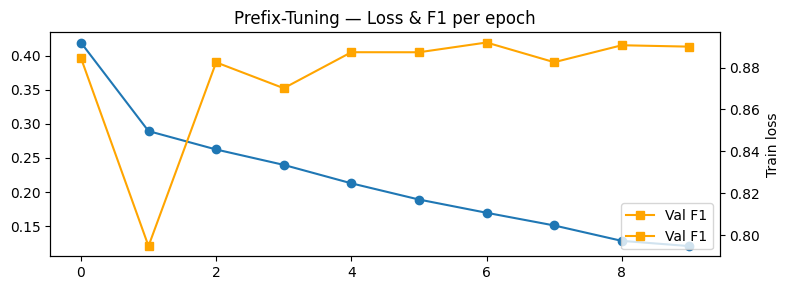

In [27]:
plt.figure(figsize=(8, 3))
plt.plot(train_losses, marker="o", label="Train loss")
f1_vals = [r["f1"] for r in eval_results]
ax2 = plt.gca().twinx()
ax2.plot(f1_vals, marker="s", color="orange", label="Val F1")
ax2.set_ylabel("Val F1")
plt.gca().set_xlabel("Epoch")
plt.gca().set_ylabel("Train loss")
plt.title("Prefix-Tuning — Loss & F1 per epoch")
lines1, labels1 = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "prefix_curve.png"), dpi=120)
plt.show()


## Đánh giá trên test set

In [28]:
metric_test_acc = evaluate.load("accuracy")
metric_test_f1  = evaluate.load("f1")

inference_model = AutoModelForSequenceClassification.from_pretrained(model_name_or_path)
inference_model = PeftModel.from_pretrained(inference_model, os.path.join(output_dir, "prefix_tuning_adapter"))
inference_model.to(device).eval()

for batch in tqdm(test_dataloader, desc="Test"):
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = inference_model(**batch)
    preds = outputs.logits.argmax(dim=-1)
    metric_test_acc.add_batch(predictions=preds.cpu(), references=batch["labels"].cpu())
    metric_test_f1.add_batch(predictions=preds.cpu(),  references=batch["labels"].cpu())

prefix_test_result = {
    "accuracy": metric_test_acc.compute()["accuracy"],
    "f1"      : metric_test_f1.compute(average="weighted")["f1"],
}
print("Prefix-Tuning Test result:", prefix_test_result)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Test: 100%|██████████| 188/188 [00:27

Prefix-Tuning Test result: {'accuracy': 0.8993333333333333, 'f1': 0.8993066980911829}


## Lưu kết quả vào biến toàn cục để so sánh sau

In [29]:
import json

prefix_summary = {
    "method"          : "Prefix-Tuning",
    "model_name"      : model_name_or_path,
    "adapter_path"    : save_path,
    "trainable_params": trainable_params,
    "trainable_pct"   : prefix_param_pct,
    "best_val_f1"     : prefix_best_f1,
    "best_val_acc"    : prefix_best_acc,
    "test_f1"         : prefix_test_result["f1"],
    "test_acc"        : prefix_test_result["accuracy"],
    "training_time_s" : prefix_training_time,
    "peak_mem_gb"     : prefix_peak_mem,
}

summary_path = os.path.join(output_dir, "prefix_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(prefix_summary, f, ensure_ascii=False, indent=2)

print(prefix_summary)
print("Saved summary to:", summary_path)


{'method': 'Prefix-Tuning', 'model_name': 'bert-base-uncased', 'adapter_path': '/kaggle/working/peft_outputs/prefix_tuning_adapter', 'trainable_params': 370178, 'trainable_pct': 0.3369728442005311, 'best_val_f1': 0.8919688780737706, 'best_val_acc': 0.892, 'test_f1': 0.8993066980911829, 'test_acc': 0.8993333333333333, 'training_time_s': 4433.085391759872, 'peak_mem_gb': 1.808864768}
Saved summary to: /kaggle/working/peft_outputs/prefix_summary.json
